In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import xarray as xr
pd.set_option('display.max_rows', 1000)
import numpy as np
import matplotlib.colors as colors

ERROR 1: PROJ: proj_create_from_database: Open of /nesi/project/niwa00018/queenle/ml_env_v2/share/proj failed


In [2]:
#METADATA
station_metadata_1 = pd.read_csv('/home/queenle/station_FWI_data/raw_metadata//aes_stnhist20210111.csv')
station_metadata_2 = pd.read_csv('/home/queenle/station_FWI_data/raw_metadata//cwfis_allstn2023.csv')
station_metadata = pd.concat([station_metadata_1,station_metadata_2])

# STATION FWI
validation_study_FWI = pd.read_csv('/home/queenle/station_FWI_data/6month_fire_season_FWI/validation_study_FWI.csv')
validation_study_FWI['rep_date'] = pd.to_datetime(validation_study_FWI['rep_date'])
validation_study_FWI.set_index('rep_date', inplace=True)

In [11]:
station_metadata_2 = pd.read_csv('/home/queenle/station_FWI_data/raw_download/cwfis_fwi1950sv3.0.csv')

In [12]:
station_metadata_2

,aes,wmo,rep_date,temp,td,rh,ws,wg,wdir,pres,...,sog,ffmc,dmc,dc,bui,isi,fwi,dsr,opts,calcstatus
0,1018610,711481,1953-01-01 12:00:00,5.6,3.9,89.0,29.0,NaN,110,1024.50,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IDW=R:M=1:,-3
1,1018620,71799,1953-01-01 12:00:00,3.3,-0.6,97.0,2.0,NaN,270,1027.70,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M=1:,-3
2,1021830,71893,1953-01-01 12:00:00,1.7,1.7,99.0,13.8,NaN,103,1024.60,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IDW=WSD:M=1:,-3
3,1026270,71109,1953-01-01 12:00:00,4.4,2.8,89.0,31.0,NaN,110,1021.50,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M=1:,-3
4,1031110,0,1953-01-01 12:00:00,4.5,2.7,87.9,26.0,NaN,108,1021.77,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IDW=T:RH:WSD:M=1:,-3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432854,2100700,71965,1959-12-31 12:00:00,-20.6,-23.9,73.0,8.0,NaN,150,1026.40,...,36.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IDW=WSD:M=1:,-3
432855,2101000,1,1959-12-31 12:00:00,-22.8,-25.0,84.0,6.2,NaN,154,1020.30,...,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IDW=WSD:M=1:,-3
432856,2101100,712098,1959-12-31 12:00:00,-16.1,-17.8,88.0,3.0,NaN,90,1029.10,...,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M=1:,-3
432857,2101200,71953,1959-12-31 12:00:00,-27.2,-29.4,82.0,3.0,NaN,90,1032.20,...,61.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M=1:,-3


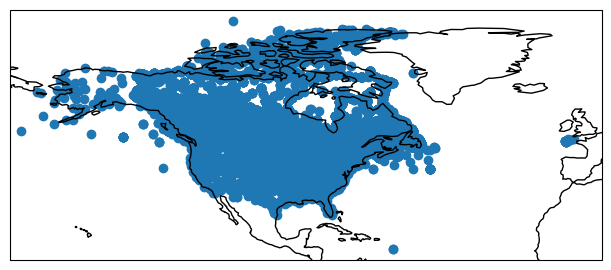

In [8]:
fig,axs = plt.subplots(figsize=(6,6),layout='constrained',subplot_kw=dict(projection=ccrs.PlateCarree()))

axs.scatter(station_metadata['lon'],station_metadata['lat'])

axs.coastlines()

In [2]:
#METADATA
station_metadata_1 = pd.read_csv('/home/queenle/station_FWI_data/raw_metadata//aes_stnhist20210111.csv')
station_metadata_2 = pd.read_csv('/home/queenle/station_FWI_data/raw_metadata//cwfis_allstn2023.csv')
station_metadata = pd.concat([station_metadata_1,station_metadata_2])

# STATION FWI
validation_study_FWI = pd.read_csv('/home/queenle/station_FWI_data/6month_fire_season_FWI/validation_study_FWI.csv')
validation_study_FWI['rep_date'] = pd.to_datetime(validation_study_FWI['rep_date'])
validation_study_FWI.set_index('rep_date', inplace=True)
validation_study_FWI = validation_study_FWI['1953':'2022']

validation_study_FWI.drop(['1092975'],axis=1,inplace=True) # drop selected sites (not enough data)
for site in ['1108446', '1086082', '3044232', '1100875', '1085836', '1046332','1017099', '1163842', '1015630', '1026562', '1047172', '1096631','1102415', '1092975']:
    validation_study_FWI.loc[validation_study_FWI.index.year==2017,site] = np.nan # remove selected 2017s (onyl have a few days in a multi-year gap)

#ERA5 FWI
box = [(32,55),(232,256)]

ERA5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/FWI_6month_fire_season_ERA5_resolution.nc')
ERA5 = ERA5.reindex(latitude=list(reversed(ERA5.latitude)))
ERA5 = ERA5.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
ERA5_canada = ERA5.sel(latitude=slice(47,box[0][1]),longitude=slice(box[1][0],box[1][1]))

# ERA5 station df
ERA5_station_dfs = []
for station in validation_study_FWI.columns:
    meta_station = station.split('.')[0]

    lat_lon = station_metadata.loc[station_metadata['aes'] == str(meta_station)][['lat','lon']]
    lat = lat_lon.values[0][0]
    lon = lat_lon.values[0][1]+360

    model_ts = ERA5.sel(latitude=lat,longitude=lon,method='nearest')
    model_df = pd.DataFrame.from_dict({'rep_date':model_ts.time,station:model_ts.data})
    model_df['rep_date'] = pd.to_datetime(model_df['rep_date'])
    model_df.set_index('rep_date', inplace=True)

    ERA5_station_dfs.append(model_df)
    
ERA5_station_df = pd.concat(ERA5_station_dfs,axis=1)


In [3]:
station_metadata

,aes,wmo,id,name,prov,cr,instr,lon,lat,elev,...,o3,ua,sns,tow,aql,nph,reg,the_geom,useindex,agency
0,704QEAQ,999999,XXXX,TOUR+WASHICOUTAI,QC,,SFC,-60.867,50.417,130,...,-,-,-,-,-,-,Q,01010000208A0F0000D004F100588A4141B18381206416...,NaN,NaN
1,704QEJ3,999999,XXXX,TOUR+LAC+TRINITE,QC,,SFC,-67.467,49.750,287,...,-,-,-,-,-,-,Q,01010000208A0F0000C2F80D2BBB413D41AD22F634C1D0...,NaN,NaN
2,704QEJC,999999,XXXX,TOUR+LALIBERTE,QC,,SFC,-68.883,49.067,305,...,-,-,-,-,-,-,Q,01010000208A0F00005A7A7500564D3C414574A6336107...,NaN,NaN
3,1010595,999999,XXXX,BAMBERTON+BC+CEMENT,BC,+,SFC,-123.517,48.583,85,...,-,-,-,-,-,-,P,01010000208A0F0000BD46B31930173FC1B7873223A285...,NaN,NaN
4,1010595,999999,XXXX,BAMBERTON+BC+CEMENT,BC,+,SFC,-123.517,48.583,85,...,-,-,-,-,-,-,P,01010000208A0F0000BD46B31930173FC1B7873223A285...,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2606,NT046,230046,CCCC,CROWN FIRE,NT,NaN,SFC,-117.165,61.583,193,...,NaN,-,NaN,NaN,NaN,NaN,NaN,01010000208A0F00005937BF77181531C1F88032B02DFF...,230046.0,NT
2607,NT047,230047,CCCC,HORN PLATEAU,NT,NaN,SFC,-117.892,62.123,296,...,NaN,-,NaN,NaN,NaN,NaN,NaN,01010000208A0F000021F87C180F4E31C14CC893936C07...,230047.0,NT
2608,WB005,3005,CCCC,PINE LAKE,NT,NaN,SFC,-112.263,59.562,267,...,NaN,-,NaN,NaN,NaN,NaN,NaN,01010000208A0F0000867BF2F9D99C2CC19E54316D019B...,3005.0,NT
2609,WB006,3006,CCCC,SWEETGRASS,NT,NaN,SFC,-111.997,58.853,211,...,NaN,-,NaN,NaN,NaN,NaN,NaN,01010000208A0F00000C05F0C53ECD2CC1A6D522E8416A...,3006.0,NT


In [4]:
for station in validation_study_FWI:
    number = site.split('.')[0]
    lat_lon = station_metadata.loc[station_metadata['aes'] == str(station)][['lat','lon']]
        
    if lat_lon.values[0][0] > 54.1:
        validation_study_FWI = validation_study_FWI.drop(station,axis=1)
        

In [5]:
'''
MEAN ABSOLUTE ERROR, MEAN PERCENTAGE ERROR, and station vs ERA5 REGIONAL TIME SERIES
'''

absolute_error_dfs = []
absolute_percent_error_dfs = []
bias_error_dfs = []
anomaly_error_dfs = []
correlation_dict = {}
for station in validation_study_FWI.columns:
    
    station_df = validation_study_FWI[station]
    ERA5_df = ERA5_station_df[station]
    
    # absolute error
    station_absolute_error = (station_df - ERA5_df).abs()
    station_absolute_error.name = station
    absolute_error_dfs.append(station_absolute_error)
    
    # absolute percentage error
    station_absolute_percent_error = ((station_df - ERA5_df)/station_df).abs()
    station_absolute_percent_error.name = station
    absolute_percent_error_dfs.append(station_absolute_percent_error)
    
    # bias error
    station_bias_error = station_df - ERA5_df
    station_bias_error.name = station
    bias_error_dfs.append(station_bias_error)
    
    # correlation
    correlation_dict[station] = [station_df.corr(ERA5_df)]
    
    # anomaly_error
    station_anomaly_error = (station_df - station_df.mean()) - (ERA5_df - ERA5_df.mean())
    station_anomaly_error.name = station
    anomaly_error_dfs.append(station_anomaly_error)
    
correlation_df = pd.DataFrame.from_dict(correlation_dict)
absolute_error_df = pd.concat(absolute_error_dfs,axis=1)
absolute_percent_error_df = pd.concat(absolute_percent_error_dfs,axis=1)
bias_error_df = pd.concat(bias_error_dfs,axis=1)
anomaly_error_df = pd.concat(anomaly_error_dfs,axis=1)


/nesi/project/niwa00015/queenle/my_env38/lib/python3.10/site-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/nesi/project/niwa00015/queenle/my_env38/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/nesi/project/niwa00015/queenle/my_env38/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


In [6]:
font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 20,
        }

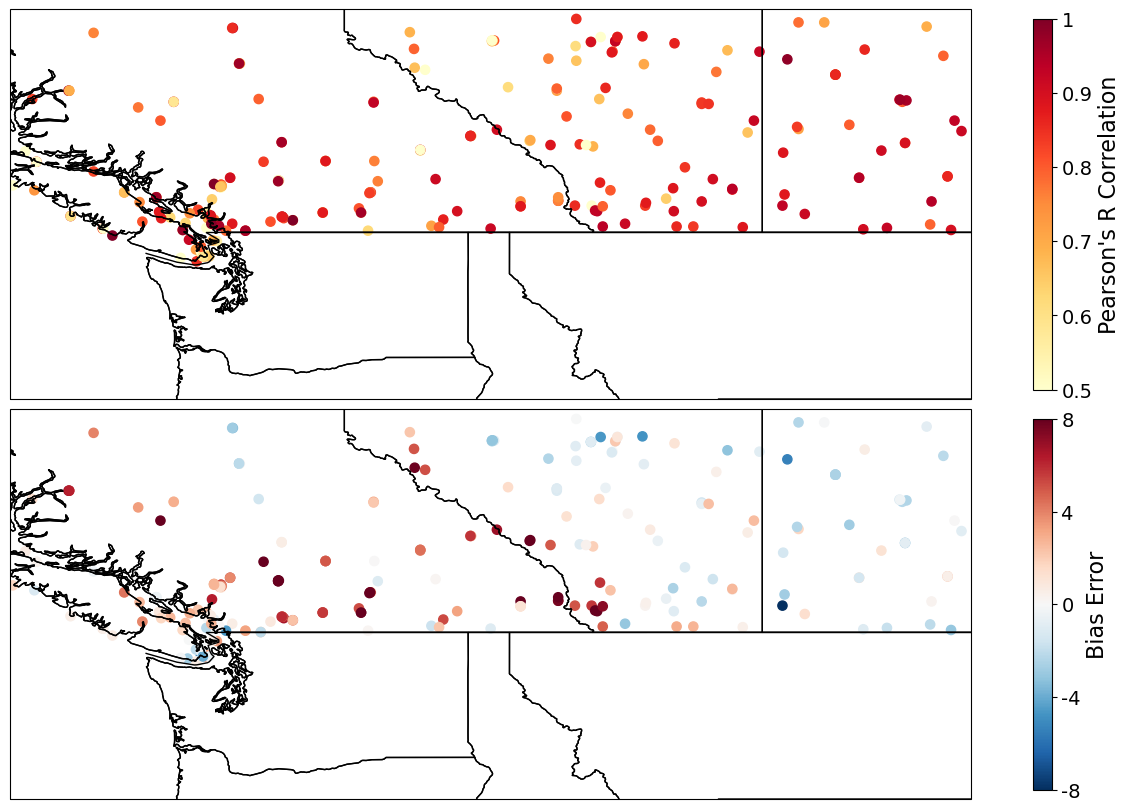

In [59]:
'''
MAPS of 
(a) bias error
(b) percentage error
(c) correlation
'''

fig,axs = plt.subplots(2,1,figsize=(14,8),layout='constrained',subplot_kw=dict(projection=ccrs.PlateCarree()))
axs = axs.flatten()

for i,df in enumerate(([correlation_df,bias_error_df])):
    
    temporal_mean = df.mean()
    
    lats = []
    lons = []
    cs = []
    for site in temporal_mean.index:
        station = site.split('.')[0]
        lat_lon = station_metadata.loc[station_metadata['aes'] == str(station)][['lat','lon']]
        lats.append(lat_lon.values[0][0])
        lons.append(lat_lon.values[0][1]+360)
        cs.append(temporal_mean[site])
        
    if i == 0:
        im = axs[i].scatter(lons,lats,c=cs,vmin=0.5,vmax=1,cmap='YlOrRd',s=44)
        cb = fig.colorbar(im, ax=axs[i], shrink=0.95, orientation='vertical')
        font['size'] = 16
        cb.set_label(label='Pearson\'s R Correlation',fontdict=font)
        font['size']=14
        cb.set_ticks([0.5,0.6,0.7,0.8,0.9,1],labels=[str(val) for val in [0.5,0.6,0.7,0.8,0.9,1]],fontdict=font)
        
    elif i == 1:
        im = axs[i].scatter(lons,lats,c=cs,vmin=-8,vmax=8,cmap='RdBu_r',s=44)
        cb = fig.colorbar(im, ax=axs[i], shrink=0.95, orientation='vertical')
        font['size'] = 16
        cb.set_label(label='Bias Error',fontdict=font)
        font['size']=14
        cb.set_ticks([-8,-4,0,4,8],labels=[str(val) for val in [-8,-4,0,4,8]],fontdict=font)

    axs[i].coastlines()  
    axs[i].add_feature(cf.BORDERS)
    axs[i].add_feature(cf.STATES)
    axs[i].set_extent([232,255, 45,54.23])

plt.savefig('/home/queenle/fire_attribution/figures/sup_mat/SupMat_Figure1.png',dpi=300,transparent=False, bbox_inches='tight')#, pad_inches=0.35)
        

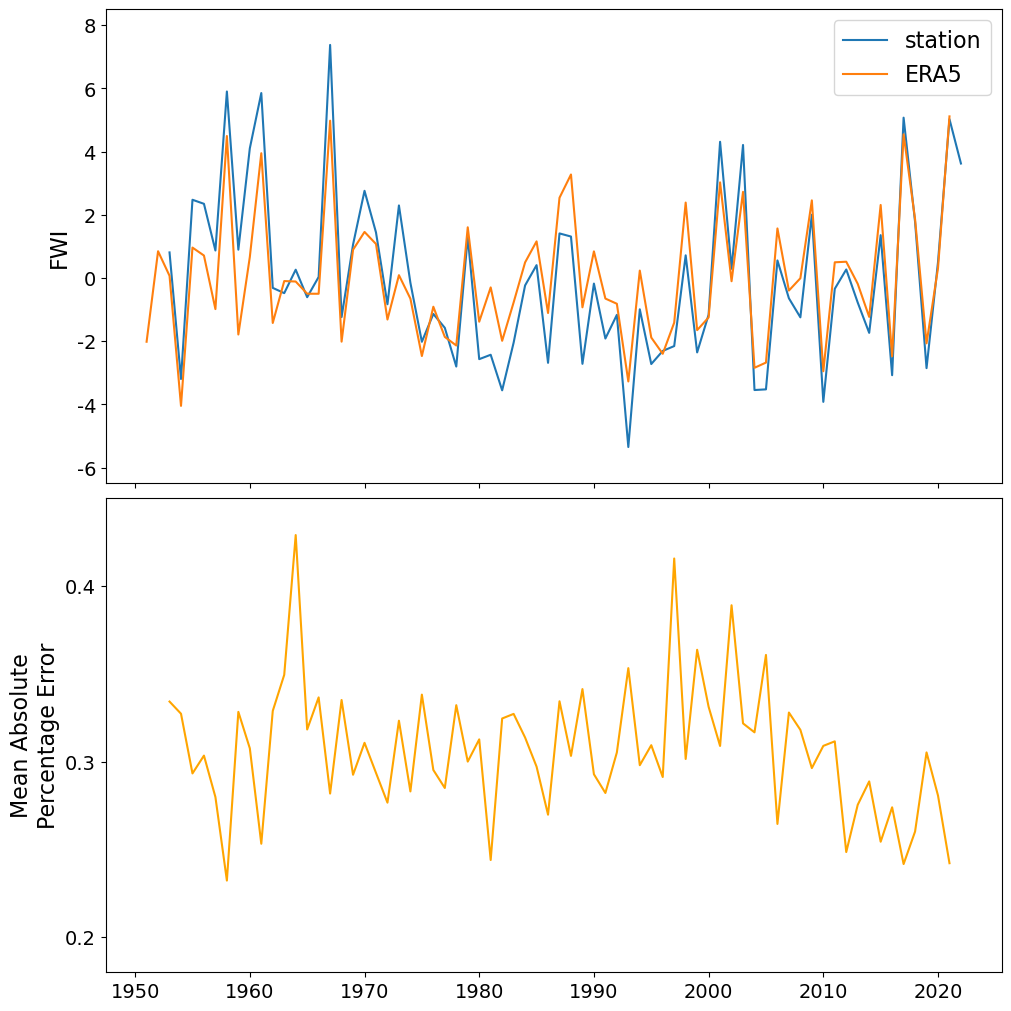

In [37]:
fig,axs = plt.subplots(2,1,figsize=(10,10),sharex=True,layout='constrained')
axs=axs.flatten()


# plot regional time series
years = validation_study_FWI.index.year.values
ts = validation_study_FWI.mean(axis=1).values
axs[0].plot(years,ts-ts.mean(),label='station')
axs[0].set_ylim(-6.5,8.5)

years = ERA5_station_df.index.year.values
ts = ERA5_station_df.mean(axis=1).values
axs[0].plot(years,ts-ts.mean(),label='ERA5')
axs[0].legend(fontsize=16)
font['size']=16
axs[0].set_ylabel('FWI',fontdict=font)
font['size']=14
axs[0].set_yticks([-6,-4,-2,0,2,4,6,8])
axs[0].set_yticklabels([str(val) for val in [-6,-4,-2,0,2,4,6,8]],fontdict=font)


# plot absolute percentage error

years = absolute_percent_error_df.index.year.values
ts = absolute_percent_error_df.mean(axis=1).values
axs[1].plot(years,ts, c='orange')
axs[1].set_ylim(0.18,0.45)
font['size']=16
axs[1].set_ylabel('Mean Absolute\nPercentage Error',fontdict=font)
font['size']=14
axs[1].set_xticks([1950+10*i for i in range(8)])
axs[1].set_xticklabels([str(1950+10*i) for i in range(8)],fontdict=font)
axs[1].set_yticks([0.2,0.3,0.4])
axs[1].set_yticklabels([str(val) for val in [0.2,0.3,0.4]],fontdict=font)

plt.savefig('/home/queenle/fire_attribution/figures/SupMat_Figure2.png',dpi=300,transparent=False, bbox_inches='tight')#, pad_inches=0.35)
